# Pakistan Education Analysis — ASER 2023
### Dropout Prediction + Gender Gap

# About dataset

- Rural Dataset
- Focus more on Primery Schools

In [1]:
#importing the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
#loading the dataset
df = pd.read_excel('D:/pakistan-education-analysis/data/ITAASER2023School.xlsx')
df.head()

,SYEAR,AREA,VMAPID,RNAME,DNAME,VlgId,VlgCode,SID,STYPE,S006,...,S014d,S014e,S014f,S014g,S013a,S013b,S013c,S013d,S013e,SURID
0,2023,2,336803,AZAD JAMMU AND KASHMIR ...,BAGH,5010,10,1,1,NaN,...,NaN,NaN,NaN,NaN,2.0,1.0,3.0,NaN,NaN,316745
1,2023,2,316762,AZAD JAMMU AND KASHMIR ...,BAGH,5019,19,2,1,NaN,...,2.0,NaN,75.0,2008.0,2.0,1.0,2.0,0.0,NaN,296705
2,2023,2,336753,AZAD JAMMU AND KASHMIR ...,BAGH,5020,20,3,1,NaN,...,4.0,NaN,150.0,2007.0,1.0,1.0,1.0,0.0,NaN,316697
3,2023,2,336771,AZAD JAMMU AND KASHMIR ...,BAGH,5001,1,4,1,NaN,...,10.0,NaN,NaN,2018.0,1.0,0.0,3.0,1.0,1.0,316716
4,2023,2,336805,AZAD JAMMU AND KASHMIR ...,BAGH,5009,9,5,1,NaN,...,6.0,NaN,50.0,NaN,2.0,1.0,3.0,0.0,NaN,316747


In [3]:
df.shape

(6095, 137)

In [4]:
df.dtypes

SYEAR       int64
AREA        int64
VMAPID      int64
RNAME      object
DNAME      object
           ...   
S013b     float64
S013c     float64
S013d     float64
S013e     float64
SURID       int64
Length: 137, dtype: object

In [6]:
df.describe()

,SYEAR,AREA,VMAPID,VlgId,SID,STYPE,S006,S00,S001,S002,...,S014d,S014e,S014f,S014g,S013a,S013b,S013c,S013d,S013e,SURID
count,6095.0,6095.0,6095.000000,6095.000000,6095.000000,6095.000000,614.000000,6095.000000,6095.000000,5885.000000,...,2718.000000,1.565000e+03,2223.000000,2372.000000,5954.000000,5258.000000,5132.000000,5113.000000,1166.000000,6095.000000
mean,2023.0,2.0,284882.442166,7444.339295,3049.206399,1.274979,1.166124,2.051025,1.625103,1.905183,...,6.746137,7.189105e+04,15.203779,2004.368044,2.213134,0.613161,2.452455,0.228046,22.906518,197659.108778
std,0.0,0.0,22058.455902,2706.762423,1760.435376,0.446541,0.489790,1.196424,0.703309,0.918787,...,3.835734,1.198057e+05,23.784366,19.474298,1.515280,0.487073,1.372489,0.419614,20.945849,108885.498363
min,2023.0,2.0,30271.000000,146.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.059000e+03,1.000000,1900.000000,1.000000,0.000000,0.000000,0.000000,1.000000,10054.000000
25%,2023.0,2.0,265637.000000,5924.500000,1524.500000,1.000000,1.000000,1.000000,1.000000,1.000000,...,5.000000,1.600000e+04,5.000000,1997.000000,1.000000,0.000000,2.000000,0.000000,7.000000,191704.500000
50%,2023.0,2.0,284956.000000,7075.000000,3050.000000,1.000000,1.000000,2.000000,1.000000,2.000000,...,7.000000,3.800000e+04,8.000000,2011.000000,1.000000,1.000000,2.000000,0.000000,20.000000,264669.000000
75%,2023.0,2.0,286090.500000,8310.000000,4573.500000,2.000000,1.000000,3.000000,2.000000,2.000000,...,8.000000,6.800000e+04,15.000000,2019.000000,3.000000,1.000000,3.000000,0.000000,30.000000,265781.000000
max,2023.0,2.0,337126.000000,22818.000000,6097.000000,2.000000,4.000000,4.000000,3.000000,4.000000,...,80.000000,1.078692e+06,300.000000,2023.000000,5.000000,1.000000,5.000000,1.000000,132.000000,317067.000000


## Data Preprocessing

In [7]:
#checking for missing values
df.isnull().sum()

SYEAR        0
AREA         0
VMAPID       0
RNAME        0
DNAME        0
          ... 
S013b      837
S013c      963
S013d      982
S013e     4929
SURID        0
Length: 137, dtype: int64

In [8]:
#dropping columns with more than 50% missing values
threshold = len(df) * 0.5
df = df.dropna(thresh=threshold, axis=1)
df.shape

(6095, 60)

In [12]:
#checking S00 column — school status
# S00 values: 1=open functional, 2=open non-functional, 3=closed temp, 4=closed permanent
df['S00'].value_counts()

S00
1    3028
4    1186
3     967
2     914
Name: count, dtype: int64

In [13]:
# creating target variable — nonfunctional school
# 1- non functional, 0- functional
df['nonfunctional'] = (df['S00'] != 1).astype(int)
df['nonfunctional'].value_counts()

nonfunctional
1    3067
0    3028
Name: count, dtype: int64

In [14]:
#checking school gender type
df['S002'].value_counts()
# 1=Boys only, 2=Girls only, 3=Mixed, 4=other

S002
2.0    2710
1.0    2174
4.0     615
3.0     386
Name: count, dtype: int64

In [15]:
#mapping school gender
df['school_gender'] = df['S002'].map({1: 'Boys Only', 2: 'Girls Only', 3: 'Mixed'})

In [17]:
#checking school type
df['STYPE'].value_counts()
# 1=Primary, 2=Middle, 3=High

STYPE
1    4419
2    1676
Name: count, dtype: int64

## Exploratory Data Analysis

In [18]:
#schools per province
df['RNAME'].value_counts()

RNAME
PUNJAB                                                1527
KHYBER PAKHTUNKHWA                                    1472
BALOCHISTAN                                           1216
SINDH                                                  811
AZAD JAMMU AND KASHMIR                                 529
GILGIT-BALTISTAN                                       488
ISLAMABAD CAPITAL TERRITORY                             52
Name: count, dtype: int64

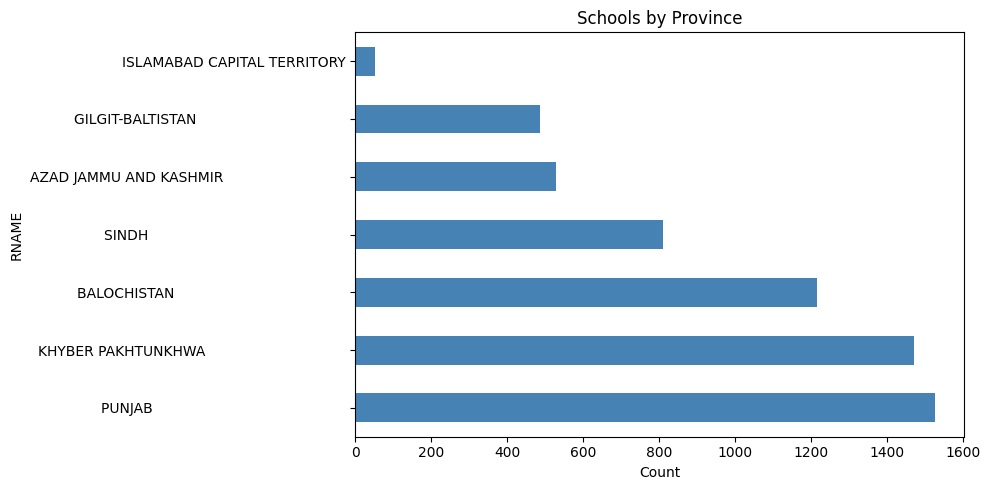

In [20]:
#plotting province distribution
df['RNAME'].value_counts().plot(kind='barh', figsize=(10,5), color='steelblue')
plt.title('Schools by Province')
plt.xlabel('Count')
plt.tight_layout()
plt.savefig('D:/pakistan-education-analysis/visuals/province_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [21]:
#non-functional rate by province
df.groupby('RNAME')['nonfunctional'].mean().sort_values(ascending=False) * 100

RNAME
GILGIT-BALTISTAN                                      68.852459
AZAD JAMMU AND KASHMIR                                66.918715
PUNJAB                                                62.540930
ISLAMABAD CAPITAL TERRITORY                           55.769231
KHYBER PAKHTUNKHWA                                    43.546196
SINDH                                                 39.334155
BALOCHISTAN                                           35.608553
Name: nonfunctional, dtype: float64

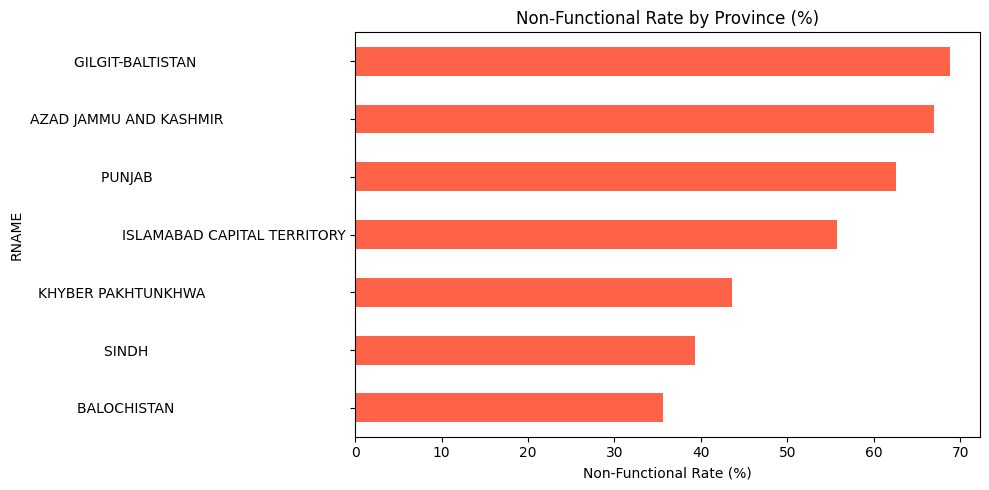

In [22]:
#plotting non-functional rate by province
prov_rate = df.groupby('RNAME')['nonfunctional'].mean().sort_values() * 100

prov_rate.plot(kind='barh', figsize=(10,5), color='tomato')
plt.title('Non-Functional Rate by Province (%)')
plt.xlabel('Non-Functional Rate (%)')
plt.tight_layout()
plt.savefig('D:/pakistan-education-analysis/visuals/non-functional rate by province.png', dpi=150, bbox_inches='tight')
plt.show()

In [23]:
#gender gap analysis
df.groupby('school_gender')['nonfunctional'].mean() * 100

school_gender
Boys Only     58.463661
Girls Only    47.601476
Mixed         33.937824
Name: nonfunctional, dtype: float64

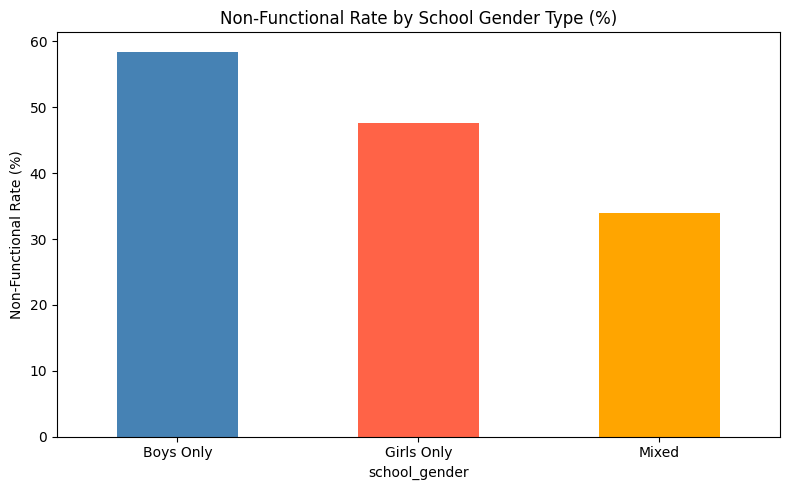

In [24]:
#plotting gender gap
gender_rate = df.groupby('school_gender')['nonfunctional'].mean() * 100

gender_rate.plot(kind='bar', figsize=(8,5), color=['steelblue','tomato','orange'], rot=0)
plt.title('Non-Functional Rate by School Gender Type (%)')
plt.ylabel('Non-Functional Rate (%)')
plt.tight_layout()
plt.savefig('D:/pakistan-education-analysis/visuals/gender gap.png', dpi=150, bbox_inches='tight')
plt.show()

In [25]:
#filtering sindh
sindh = df[df['RNAME'].str.contains('SINDH', case=False, na=False)]
print(sindh.shape)
sindh['nonfunctional'].mean() * 100

(811, 62)


np.float64(39.33415536374846)

In [26]:
#sindh district level non-functional rate
sindh.groupby('DNAME')['nonfunctional'].mean().sort_values(ascending=False).head(15) * 100

DNAME
KARACHI WEST           70.909091
THATTA                 66.666667
KARACHI MALIR          62.000000
NAUSHAHRO FEROZE       61.290323
TANDO MUHAMMAD KHAN    53.125000
SUJAWAL                51.515152
DADU                   46.666667
BADIN                  43.333333
THARPARKAR             41.935484
KHAIRPUR               41.666667
MATIARI                40.000000
GHOTKI                 39.393939
LARKANA                36.842105
MIRPUR KHAS            35.483871
SANGHAR                31.034483
Name: nonfunctional, dtype: float64

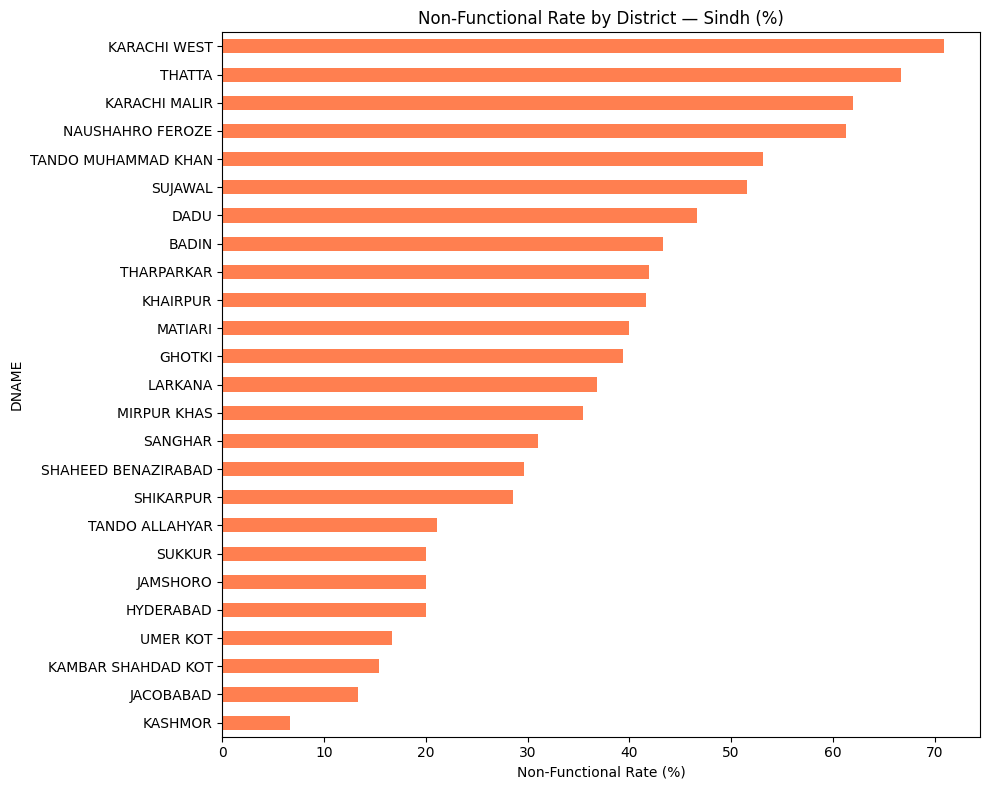

In [27]:
#plotting sindh district rates
sindh_dist = sindh.groupby('DNAME')['nonfunctional'].mean().sort_values() * 100

sindh_dist.plot(kind='barh', figsize=(10,8), color='coral')
plt.title('Non-Functional Rate by District — Sindh (%)')
plt.xlabel('Non-Functional Rate (%)')
plt.tight_layout()
plt.savefig('D:/pakistan-education-analysis/visuals/sindh_district_rates.png', dpi=150, bbox_inches='tight')
plt.show()

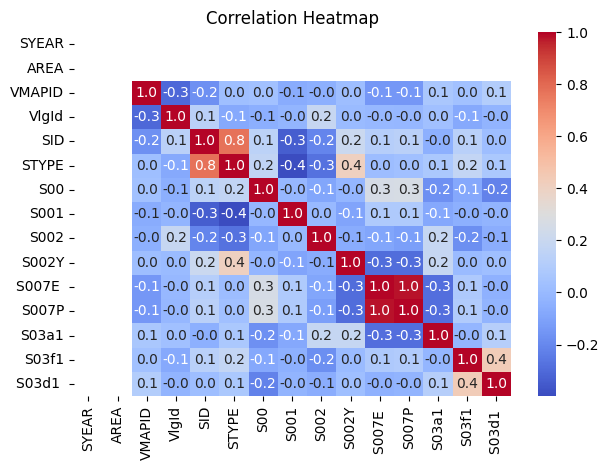

In [28]:
#correlation heatmap
num_cols = df.select_dtypes(include='number').columns[:15]
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', fmt='.1f')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig('D:/pakistan-education-analysis/visuals/correlatin_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## Saving Clean Dataset

In [29]:
#keeping useful columns for ml model
keep_cols = ['RNAME', 'DNAME', 'STYPE', 'S001', 'S002',
             'S007E', 'S007P', 'S03d1', 'S03e1', 'S03f1',
             'school_gender', 'nonfunctional']

keep_cols = [c for c in keep_cols if c in df.columns]
df_clean = df[keep_cols].copy()
df_clean.shape

(6095, 10)

In [30]:
#checking nulls in clean dataset
df_clean.isnull().sum()

RNAME              0
DNAME              0
STYPE              0
S001               0
S002             210
S007P              0
S03e1            310
S03f1            358
school_gender    825
nonfunctional      0
dtype: int64

In [31]:
#filling remaining nulls with 0
df_clean = df_clean.fillna(0)
df_clean.isnull().sum()

RNAME            0
DNAME            0
STYPE            0
S001             0
S002             0
S007P            0
S03e1            0
S03f1            0
school_gender    0
nonfunctional    0
dtype: int64

In [33]:
#saving the clean dataset
df_clean.to_csv('D:/pakistan-education-analysis/data/aser_2023_clean.csv', index=False)
print('saved: aser_2023_clean.csv')

saved: aser_2023_clean.csv
